Aluno: Lucas Barbosa dos Santos

#ARIMA

In [ ]:
!pip install "numpy<2" pmdarima

In [ ]:
from pmdarima.arima import auto_arima

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [9]:
from google.colab import drive

drive.mount("/content/drive")
file_path = "/content/drive/My Drive/Colab Notebooks"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
df = pd.read_csv(f"{file_path}/NFLX.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   object 
 1   Open       1009 non-null   float64
 2   High       1009 non-null   float64
 3   Low        1009 non-null   float64
 4   Close      1009 non-null   float64
 5   Adj Close  1009 non-null   float64
 6   Volume     1009 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 55.3+ KB


In [5]:
df.isna().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [11]:
df["Date"] = pd.to_datetime(df["Date"])

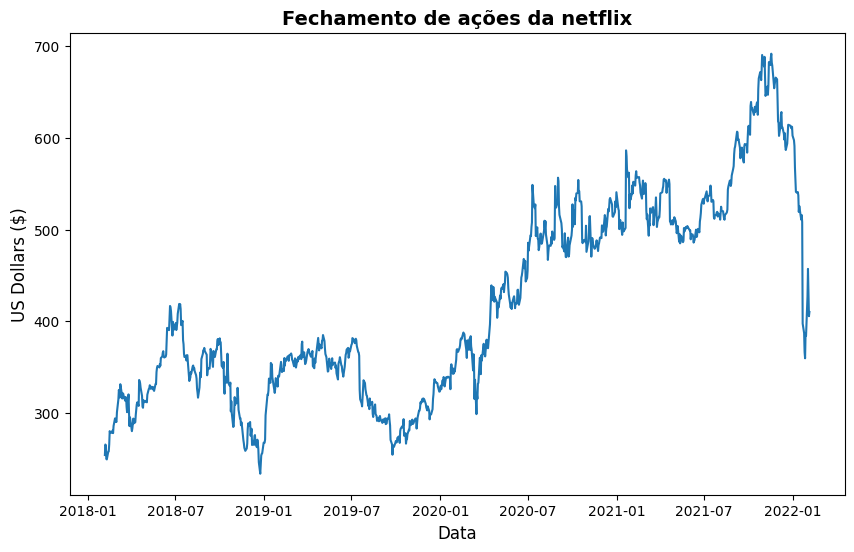

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df['Date'], df['Close'])
ax.set_title("Fechamento de ações da netflix", fontsize=14, fontweight="bold")
ax.set_xlabel("Data", fontsize=12)
ax.set_ylabel("US Dollars ($)", fontsize=12)
plt.show()

In [12]:
df.set_index("Date", inplace=True)

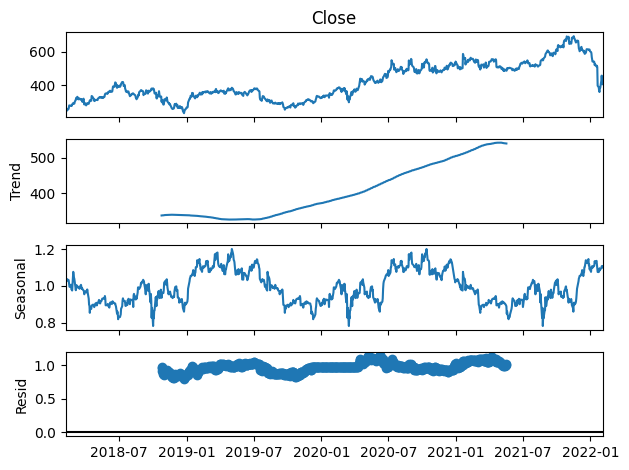

In [9]:
result = seasonal_decompose(df['Close'], model='multiplicative', period=365)
result.plot()
plt.show()

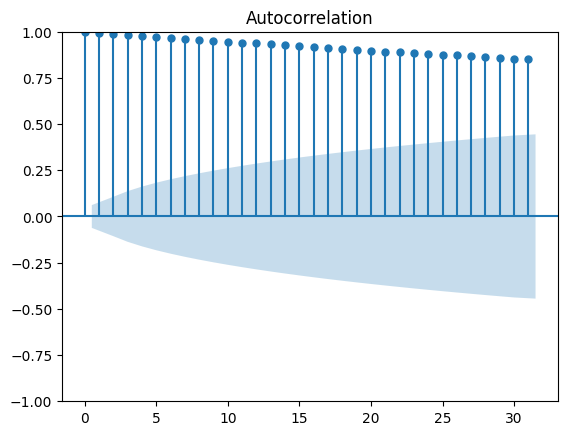

In [ ]:
plot_acf(df["Close"])
plt.show()

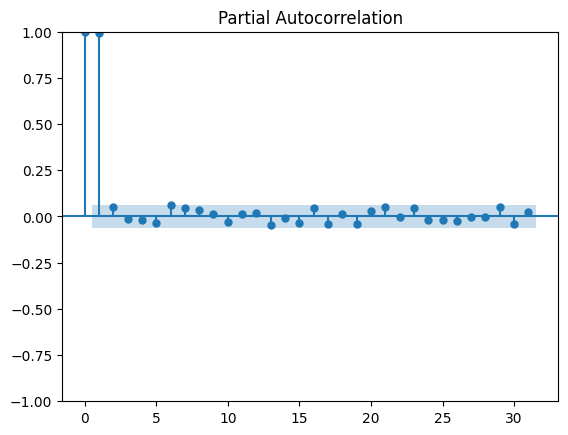

In [ ]:
plot_pacf(df["Close"])
plt.show()

In [ ]:
def test_stationarity(series):
    # KPSS Test
    kpss_stat, kpss_p, _, _ = kpss(series, regression='c')
    print(f"KPSS p-value: {kpss_p}")
    if kpss_p < 0.05:
        print("❌ KPSS: Série NÃO é estacionária.")
    else:
        print("✅ KPSS: Série estacionária.")

In [ ]:
test_stationarity(df['Close'])

KPSS p-value: 0.01
❌ KPSS: Série NÃO é estacionária.


In [ ]:
def differentiate(data: pd.DataFrame | pd.Series, m: int = 1):
  diffs = []
  for t in range(m, len(data)):
    diffs.append(data.values[t] - data.values[t - m])

  return pd.DataFrame({f"Diff(m={m})": diffs})

In [ ]:
df_diff = differentiate(df["Close"])

In [ ]:
test_stationarity(df_diff['Diff(m=1)'])

KPSS p-value: 0.1
✅ KPSS: Série estacionária.


Text(0.5, 1.0, 'Serie diferenciada m = 1')

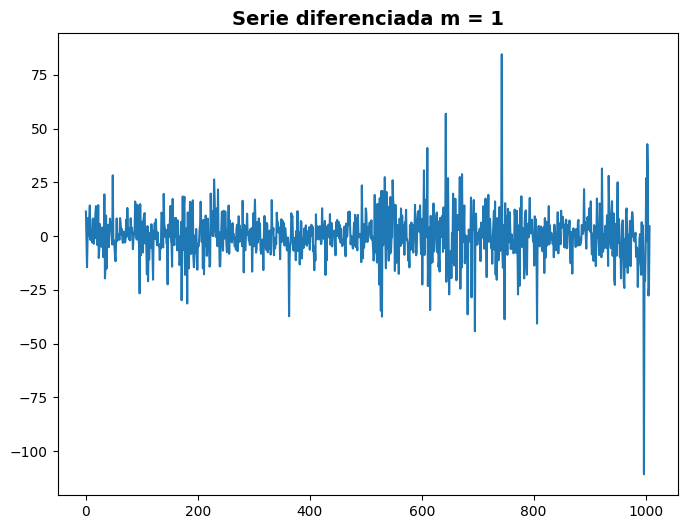

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(df_diff.index, df_diff['Diff(m=1)'])
ax.set_title("Serie diferenciada m = 1", fontsize=14, fontweight="bold")

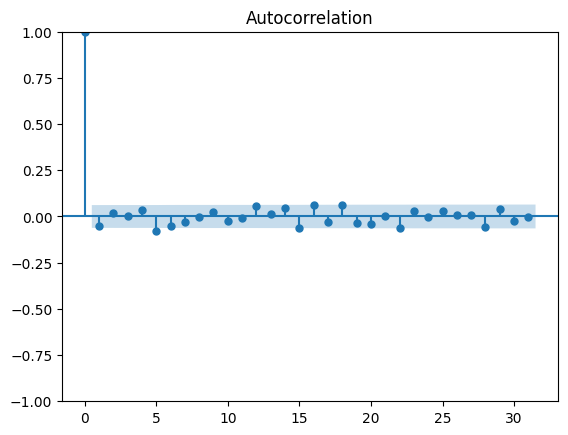

In [ ]:
plot_acf(df_diff["Diff(m=1)"])
plt.show()

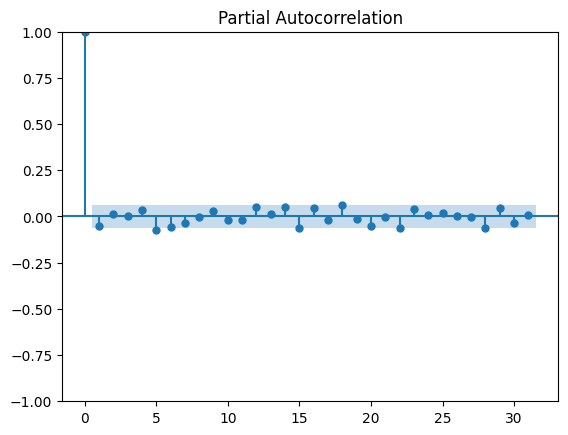

In [ ]:
plot_pacf(df_diff["Diff(m=1)"])
plt.show()

In [ ]:
ts = df['Close'].values
test_size = int(len(ts) * 0.2)
train, test = ts[:-test_size], ts[-test_size:]

In [ ]:
def mse(gt: any, pred: any) -> float:
    return np.square(gt - pred).mean()

def rmse(gt: any, pred: any) -> float:
    return np.sqrt(mse(gt, pred))

def mae(gt: any, pred: any) -> float:
    return np.abs(gt - pred).mean()

def mape(gt: any, pred: any) -> float:
    # Evita divisão por zero
    gt = np.where(gt == 0, np.finfo(float).eps, gt)
    return (np.abs((gt - pred) / gt).mean()) * 100

def get_metrics(gt: any, pred: any) -> dict:
    metrics = {
        "mae": mae(gt, pred),
        "rmse": rmse(gt, pred),
        "mape": mape(gt, pred)
    }
    return metrics

In [ ]:
model_auto = auto_arima(train,
                       Q=0,
                       P=2,
                       q=2,
                       p=2,
                       d=1,
                       D=1,
                       m=12,
                       seazonal=True,
                       trace=True,
                       information_criterion="aic",
                       stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=inf, Time=30.33 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=6511.391, Time=0.07 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=6319.424, Time=0.46 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=2.18 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=6503.023, Time=0.15 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=6254.612, Time=0.98 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=13.27 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=4.13 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=6268.824, Time=0.80 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=6256.222, Time=1.54 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=6253.676, Time=2.54 sec
 ARIMA(1,1,1)(1,1,0)[12]             : AIC=6318.641, Time=2.64 sec
 ARIMA(1,1,1)(2,1,1)[12]             : AIC=inf, Time=17.90 sec
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=inf, Time=7.12 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=625

<Axes: >

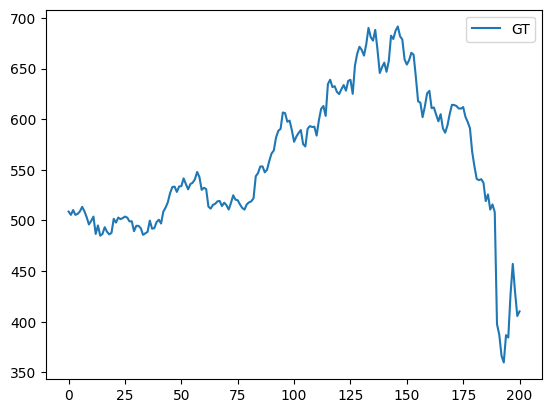

In [ ]:
results = {"GT": test}
df_results = pd.DataFrame(results)
df_results.plot()

In [ ]:
arima_preds = model_auto.predict(len(results["GT"]))

In [ ]:
arima_results = get_metrics(results["GT"], arima_preds)
arima_results

{'mae': 162.84506080041382,
 'rmse': 198.47095798839942,
 'mape': 27.59477108655065}

<Axes: >

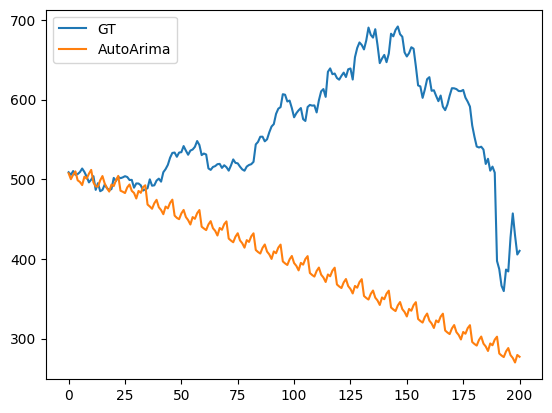

In [ ]:
results["AutoArima"] = arima_preds

df_results = pd.DataFrame(results)
df_results.plot()

In [ ]:
sarima_model = SARIMAX(
    train,
    order=(2, 1, 3),               # parte não sazonal
    seasonal_order=(2, 1, 0,  60),     # parte sazonal
    enforce_stationarity=False,
    enforce_invertibility=False
)

In [ ]:
sarima_results = sarima_model.fit().predict(start=len(train),
                                    end=len(train) + len(test) - 1)

<Axes: >

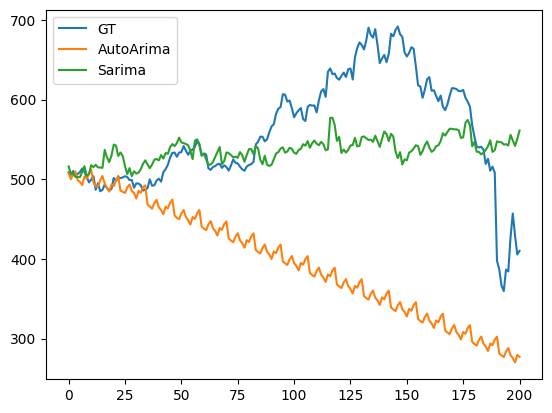

In [ ]:
results["Sarima"] = sarima_results

df_results = pd.DataFrame(results)
df_results.plot()

In [ ]:
sarima_results2 = get_metrics(results["GT"], results["Sarima"])
sarima_results2

{'mae': 51.703430905584845,
 'rmse': 69.41924631739695,
 'mape': 9.212965916610163}

In [ ]:
sarima_preds = pd.DataFrame(results["Sarima"], index=df.index[-len(results["GT"]):],columns=['Close'])

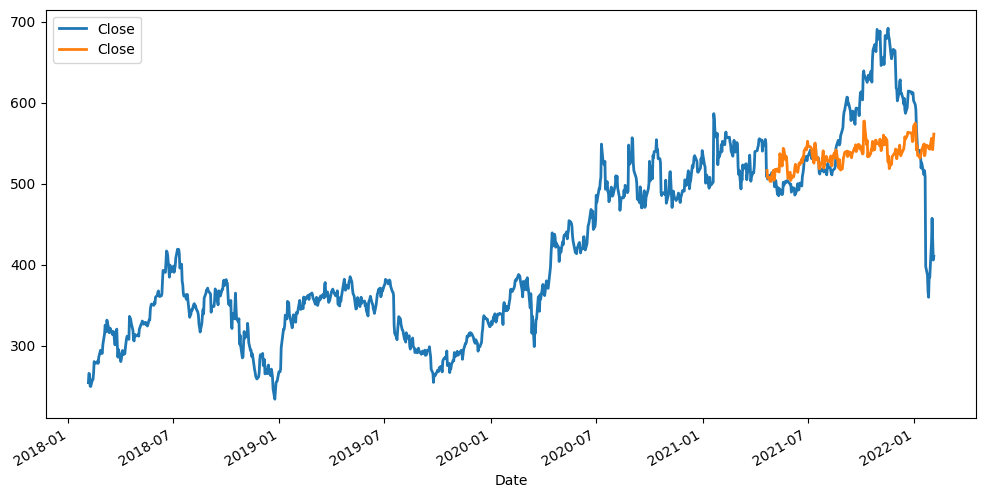

In [ ]:
pd.concat([df['Close'], sarima_preds], axis=1).plot(
    linewidth=2,  # espessura das linhas
    figsize=(12,6) # largura x altura do gráfico
)
plt.show()

In [ ]:
df_results.to_csv("results.csv", index=False)

In [ ]:
sarima=pd.DataFrame([sarima_results2])


In [ ]:
sarima.to_csv("sarima.csv", index=False)

#MLP

In [13]:
!pip install tsai

In [14]:
from tsai.all import *

In [15]:
target = df["Close"]

In [16]:
seq_len = 4

X, y = SlidingWindow(window_len=seq_len,   # tamanho da janela
                     horizon=1,    # quantos passos à frente prever
                     stride=1)(target.values)

X.shape, y.shape

((1005, 1, 4), (1005,))

In [17]:
split_idx = int(len(X) * 0.8)
splits = (list(range(split_idx)), list(range(split_idx, len(X))))

X      - shape: [1005 samples x 1 features x 4 timesteps]  type: ndarray  dtype:float64  isnan: 0
y      - shape: (1005,)  type: ndarray  dtype:float64  isnan: 0
splits - n_splits: 2 shape: [804, 201]  overlap: False


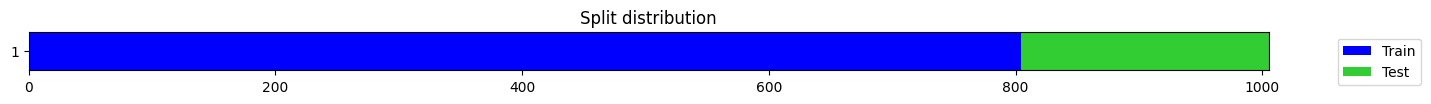

In [18]:
check_data(X, y, splits)

In [19]:
batch_tfms = TSStandardize()
dls = get_ts_dls(X, y, splits=splits, bs=64, batch_tfms=batch_tfms)

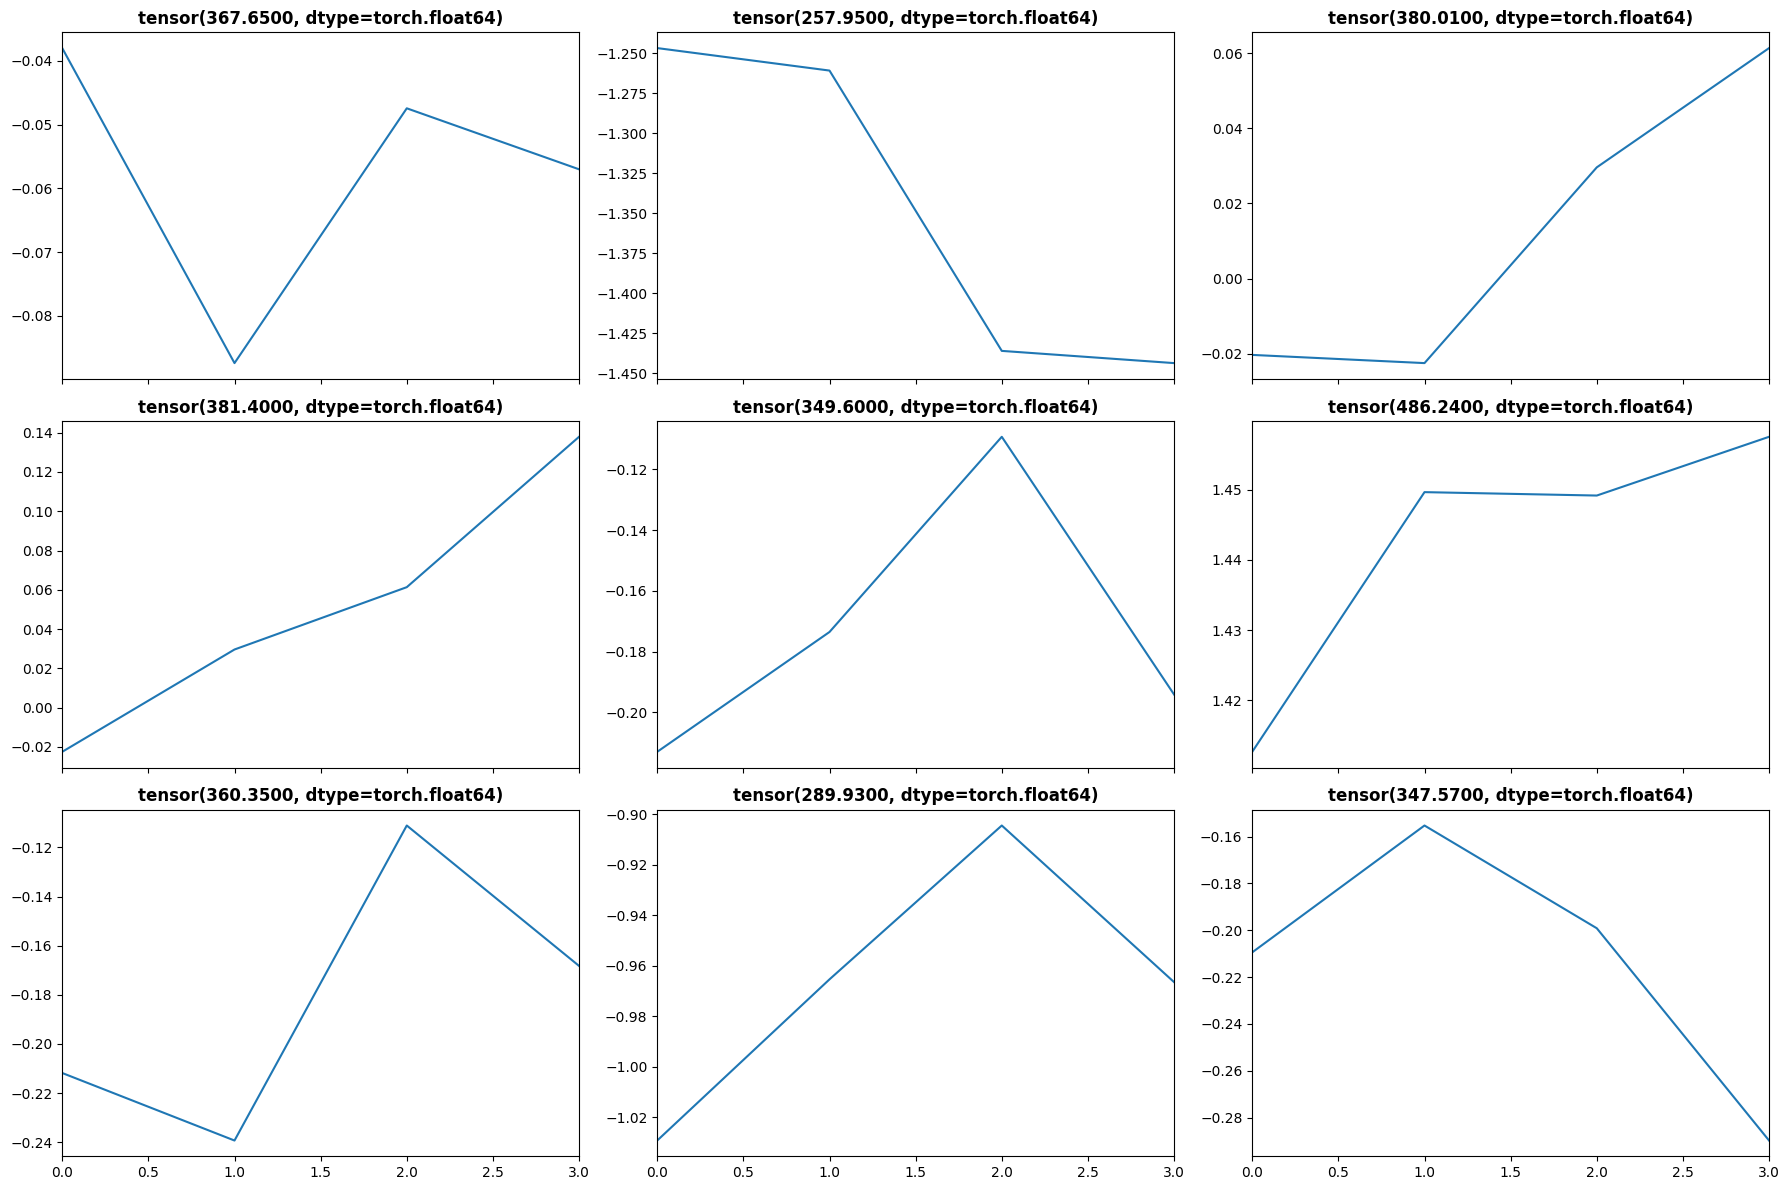

In [20]:
dls.show_batch()

In [21]:
learn = ts_learner(dls, MLP, metrics=[mae, rmse, mape])

SuggestedLRs(valley=0.0030199517495930195)

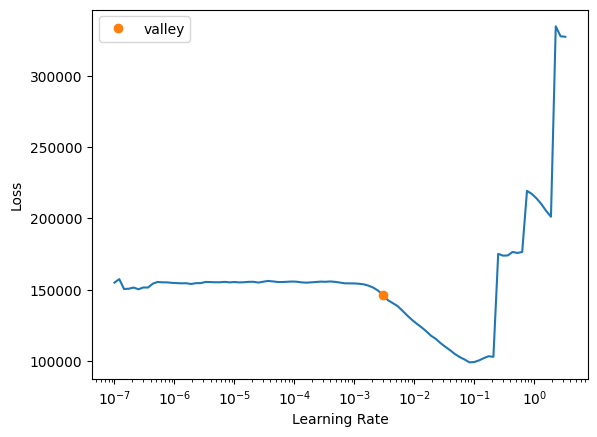

In [22]:
learn.lr_find()

In [23]:
learn.fit_one_cycle(30,1e-3)

epoch,train_loss,valid_loss,mae,_rmse,mape,time
0,154974.859375,315251.750000,557.066833,561.472839,0.998552,00:00
1,155123.078125,312170.656250,554.397949,558.722351,0.993880,00:00
2,153917.953125,292109.187500,536.683472,540.471191,0.962891,00:00
3,146875.625000,169296.093750,410.512878,411.456055,0.742193,00:00
4,119361.281250,110391.007812,276.846344,332.251434,0.468574,00:00
5,92582.585938,13396.937500,94.915939,115.745140,0.166905,00:00
6,71707.390625,33650.332031,143.205765,183.440262,0.240111,00:00
7,55363.453125,11067.586914,79.277832,105.202591,0.133729,00:00
8,42690.695312,3856.221924,49.683628,62.098488,0.086553,00:00
9,32965.613281,2363.792969,36.314980,48.618855,0.062879,00:00


In [24]:
MLP_preds, targets = learn.get_preds(ds_idx=1)

In [25]:
MLP_preds.shape, targets.shape

(torch.Size([201, 1]), torch.Size([201]))

In [26]:
MLP_preds = MLP_preds.numpy().flatten()
targets = targets.numpy().flatten()

In [27]:
mae_MLP = mean_absolute_error(targets, MLP_preds)
mse_MLP = mean_squared_error(targets, MLP_preds)
rmse_MLP = np.sqrt(mse_MLP)
mape_MLP = np.mean(np.abs((targets - MLP_preds) / targets)) * 100  # porcentagem

print(f"MAE: {mae_MLP:.3f}, RMSE: {rmse_MLP:.3f}, MAPE: {mape_MLP:.2f}%")


MAE: 19.446, RMSE: 24.707, MAPE: 3.65%


In [28]:
df_val = df.iloc[-len(targets):].copy()  # pega os últimos 20%
df_val['Predicted'] = MLP_preds

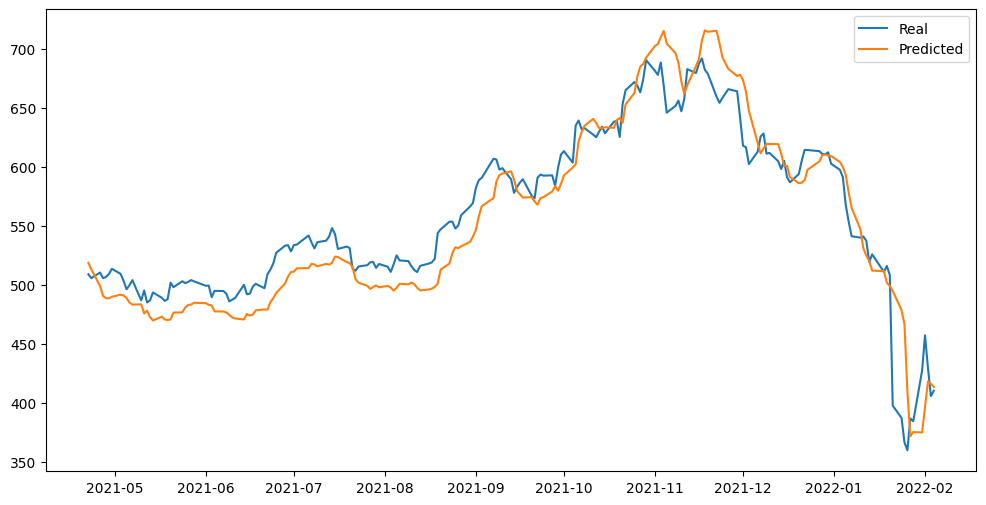

In [29]:
plt.figure(figsize=(12,6))
plt.plot(df_val.index, df_val['Close'], label='Real')
plt.plot(df_val.index, df_val['Predicted'], label='Predicted')
plt.legend()
plt.show()

#MiniRocket + Regressor

In [33]:
seq_len = 20 #Não aceita o seq_len de 4, pois é muito pequeno

X, y = SlidingWindow(window_len=seq_len,   # tamanho da janela
                     horizon=1,    # quantos passos à frente prever
                     stride=1)(target.values)

X.shape, y.shape

((989, 1, 20), (989,))

In [34]:
split_idx = int(len(X) * 0.8)
splits = (list(range(split_idx)), list(range(split_idx, len(X))))

In [35]:
X_train, y_train = X[splits[0]], y[splits[0]]
X_valid, y_valid = X[splits[1]], y[splits[1]]

In [36]:
X_train.shape, y_train.shape, X_valid.shape, y_valid.shape

((791, 1, 20), (791,), (198, 1, 20), (198,))

In [37]:
X_train = X_train.astype('float32')
X_valid = X_valid.astype('float32')

mrf = MiniRocketFeatures(c_in=X_train.shape[1], seq_len=X_train.shape[2])

# Treina MiniRocket no treino
mrf.fit(X_train[splits[0]])

In [38]:
X = X.astype('float32')
# Extrai features
X_train_tfm = get_minirocket_features(X[splits[0]], model=mrf)
X_valid_tfm = get_minirocket_features(X[splits[1]], model=mrf)

print(X_train_tfm.shape, X_valid_tfm.shape)

torch.Size([791, 9996, 1]) torch.Size([198, 9996, 1])


In [39]:
X_train_tfm = X_train_tfm.reshape(X_train_tfm.shape[0], -1)
X_valid_tfm = X_valid_tfm.reshape(X_valid_tfm.shape[0], -1)

print(X_train_tfm.shape, X_valid_tfm.shape)

torch.Size([791, 9996]) torch.Size([198, 9996])


In [40]:
xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
xgb.fit(X_train_tfm, y[splits[0]])

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [41]:
xgb_preds = xgb.predict(X_valid_tfm)

In [42]:
mae_xgb = mean_absolute_error(y[splits[1]], xgb_preds)
mse_xgb = mean_squared_error(y[splits[1]], xgb_preds)
rmse_xgb = np.sqrt(mse_xgb)
mape_xgb = np.mean(np.abs((y[splits[1]] - xgb_preds) / y[splits[1]])) * 100  # porcentagem

print(f"MAE: {mae_xgb:.3f}, RMSE: {rmse_xgb:.3f}, MAPE: {mape_xgb:.2f}%")

MAE: 50.187, RMSE: 68.982, MAPE: 8.35%


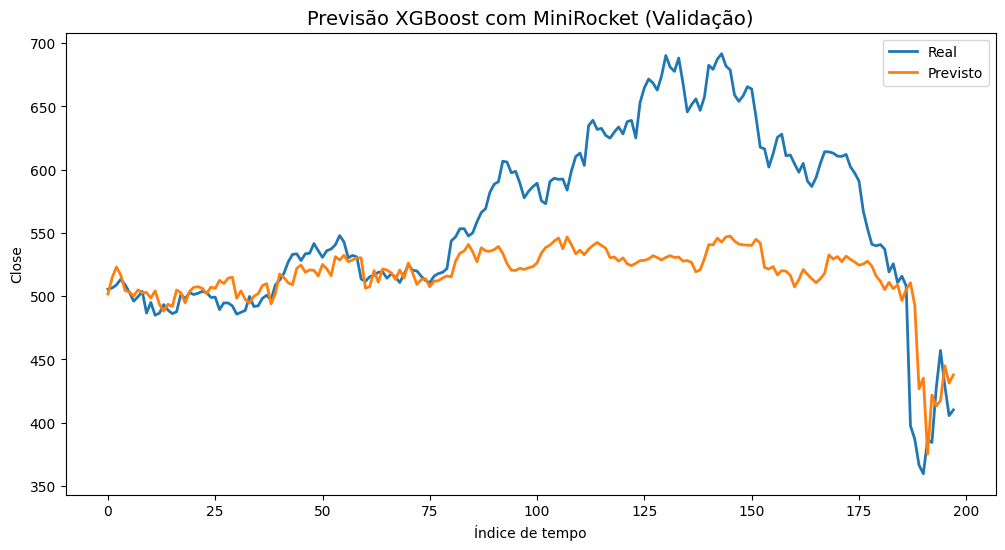

In [43]:
y_valid = y[splits[1]]

plt.figure(figsize=(12,6))
plt.plot(y_valid, label="Real", linewidth=2)
plt.plot(xgb_preds, label="Previsto", linewidth=2)
plt.title("Previsão XGBoost com MiniRocket (Validação)", fontsize=14)
plt.xlabel("Índice de tempo")
plt.ylabel("Close")
plt.legend()
plt.show()

#Prophet

In [55]:
!pip install prophet plotly

In [56]:
from prophet import Prophet

In [50]:
df_prophet = df.copy()
df_prophet = df_prophet.reset_index().rename(columns={'index':'Date'}) if 'Date' not in df.columns else df.copy()

In [51]:
df_prophet = df_prophet[['Date', 'Close']].dropna().copy()
df_prophet['Date'] = pd.to_datetime(df_prophet['Date'])
df_prophet = df_prophet.sort_values('Date')

In [52]:
df_p = df_prophet.rename(columns={'Date':'ds', 'Close':'y'})

In [53]:
n = len(df_p)
n_val = int(np.ceil(0.2 * n))
train = df_p.iloc[:-n_val].copy()
valid = df_p.iloc[-n_val:].copy()

In [57]:
m = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode='additive'
)
m.fit(train)

DEBUG:cmdstanpy:input tempfile: /tmp/tmpkny301h_/02gdkgkq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpkny301h_/cag95poi.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=930', 'data', 'file=/tmp/tmpkny301h_/02gdkgkq.json', 'init=/tmp/tmpkny301h_/cag95poi.json', 'output', 'file=/tmp/tmpkny301h_/prophet_modelogkrizaw/prophet_model-20250901234544.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
23:45:44 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
23:45:46 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [58]:
future = valid[['ds']].copy()   # mesmas datas do bloco de validação
fcst = m.predict(future)

# Juntar real x previsto
out = valid[['ds','y']].merge(fcst[['ds','yhat','yhat_lower','yhat_upper']], on='ds', how='left')

In [59]:
out.head()

,ds,y,yhat,yhat_lower,yhat_upper
0,2021-04-21,508.899994,564.477037,540.973635,588.231891
1,2021-04-22,508.779999,565.551611,540.588460,589.308918
2,2021-04-23,505.549988,564.417635,539.939859,585.364303
3,2021-04-26,510.299988,566.091673,543.413534,589.130246
4,2021-04-27,505.549988,568.342884,544.506850,591.499939


In [67]:
mae  = mean_absolute_error(out['y'], out['yhat'])
rmse = np.sqrt(mean_squared_error(out['y'], out['yhat']))  # RMSE "na mão"
mape = np.mean(np.abs((out['y'] - out['yhat']) / out['y'])) * 100

print(f"MAE: {mae:.3f}  RMSE: {rmse:.3f}  MAPE: {mape:.2f}%")

MAE: 68.453  RMSE: 86.535  MAPE: 13.51%


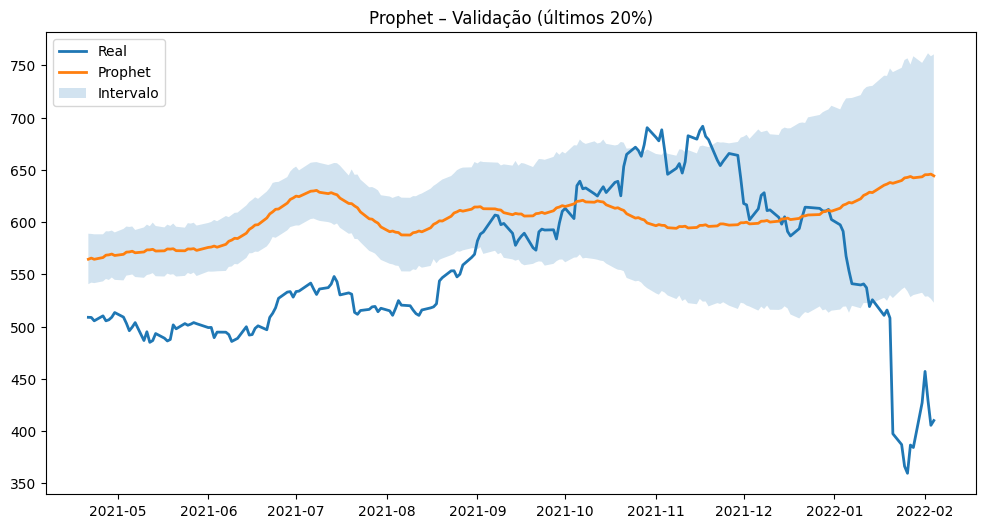

In [47]:
plt.figure(figsize=(12,6))
plt.plot(out['ds'], out['y'], label='Real', linewidth=2)
plt.plot(out['ds'], out['yhat'], label='Prophet', linewidth=2)
plt.fill_between(out['ds'], out['yhat_lower'], out['yhat_upper'], alpha=0.2, label='Intervalo')
plt.title('Prophet – Validação (últimos 20%)')
plt.legend()
plt.show()

In [45]:
results= pd.read_csv("results.csv")
results.head()

,GT,AutoArima,Sarima
0,508.779999,507.472113,516.181130
1,505.549988,500.108653,506.933265
2,510.299988,505.754937,507.556242
3,505.549988,509.880846,502.872017
4,506.519989,498.704910,502.881392


In [60]:
results["MLP"] = MLP_preds
results["Prophet"]=out['yhat']
#Não deu para adicionar o Rocket+XGB pois o rocket não aceita seq_len de 4, ai a quantidade de linhas de preds ficou diferente

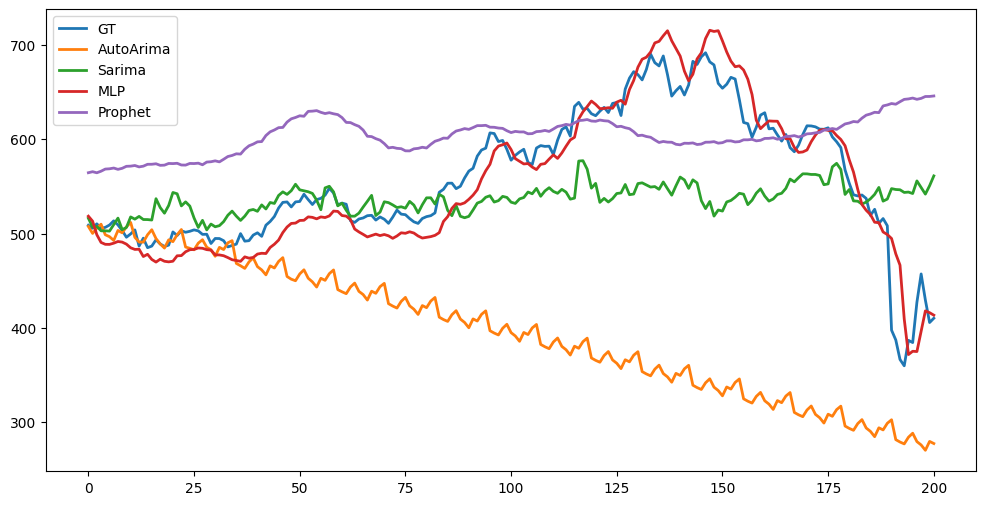

In [64]:
results.plot(linewidth=2, figsize=(12,6))
plt.show()

In [69]:
erros = {
    'XGB': {
        'MAE': mae_xgb,
        'RMSE': rmse_xgb,
        'MAPE': mape_xgb
    },
    'MLP': {
        'MAE': mae_MLP,
        'RMSE': rmse_MLP,
        'MAPE': mape_MLP
    },
    'Prophet': {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape
    }
}

In [88]:
df_erros = pd.DataFrame(erros).T  # .T para transpor
df_erros = df_erros.reset_index().rename(columns={'index': 'Modelo'})

print(df_erros)

    Modelo        MAE       RMSE       MAPE
0      XGB  50.187454  68.981903   8.345225
1      MLP  19.446271  24.707103   3.645408
2  Prophet  68.452857  86.534759  13.511673


In [73]:
Sarima= pd.read_csv("sarima.csv")
Sarima

,mae,rmse,mape
0,51.703431,69.419246,9.212966


In [89]:
# Linha SARIMA com mesmas colunas
nova_linha = pd.DataFrame({
    'MAE': [51.70],
    'RMSE': [69.42],
    'MAPE': [9.21],
    'Modelo': ['SARIMA']
})

# Concatenar com df existente
df_erros = pd.concat([df_erros, nova_linha], ignore_index=True)

In [90]:
df_erros

,Modelo,MAE,RMSE,MAPE
0,XGB,50.187454,68.981903,8.345225
1,MLP,19.446271,24.707103,3.645408
2,Prophet,68.452857,86.534759,13.511673
3,SARIMA,51.700000,69.420000,9.210000


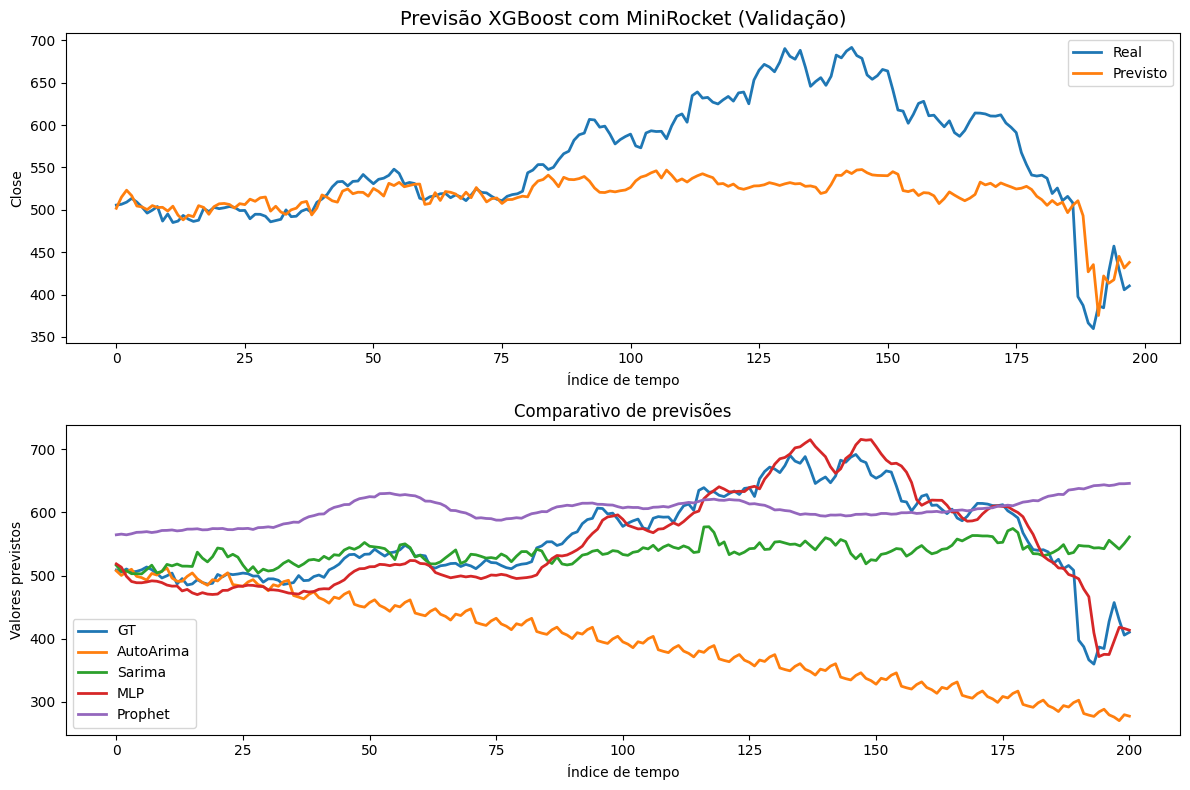

In [94]:
plt.figure(figsize=(12,8))

# Gráfico 1: Real vs XGBoost
plt.subplot(2,1,1)  # 2 linhas, 1 coluna, primeiro gráfico
plt.plot(y_valid, label="Real", linewidth=2)
plt.plot(xgb_preds, label="Previsto", linewidth=2)
plt.title("Previsão XGBoost com MiniRocket (Validação)", fontsize=14)
plt.xlabel("Índice de tempo")
plt.ylabel("Close")
plt.legend()

# Gráfico 2: todos os resultados do DataFrame
plt.subplot(2,1,2)  # 2 linhas, 1 coluna, segundo gráfico
results.plot(linewidth=2, ax=plt.gca())
plt.title("Comparativo de previsões")
plt.xlabel("Índice de tempo")
plt.ylabel("Valores previstos")
plt.legend()

plt.tight_layout()
plt.show()